<a href="https://colab.research.google.com/github/rushitpatel2311/Group_7_Deepfake_Detection/blob/Om/Group_7_Deepfake_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group 7 — AI-Driven Deepfake Detection System

**Module:** AI Systems Engineering (CMP-L044) — Part 2 Artefact

---

## Notebook Structure

| Section | Lead | Description |
|---------|------|-------------|
| **Section 0** | Rushitkumar Patel (A00085504) | Install packages, dataset setup, global config |
| **Section 1** | Isha Luhar (A00085061) | Data ingestion, MTCNN preprocessing, Mel spectrograms |
| **Section 2** | Nishtha Solanki (A00087199) | Video pipeline — EfficientNet-B4 + Transformer |
| **Section 3** | Nishtha Solanki (A00087199) | Audio pipeline — ResNet-18 on Mel spectrograms |
| **Section 4** | Rushitkumar Patel (A00085504) | Late fusion meta-learner + Grad-CAM explainability |
| **Section 5** | OM Mistry (A00067376) | Evaluation, robustness, fairness, MLflow logging |

---

## Before You Run

1. **Runtime → Change runtime type → T4 GPU** (required)
2. **Add Kaggle .json file of Legacy API Credentials to 0.2 of Environment setup section**
3. Run cells **strictly top to bottom** — all sections are interdependent
4. If Colab disconnects, re-run from Cell 0.1 (packages reset each session)

---


# SECTION 0 — Environment Setup
**Rushitkumar Patel (A00085504)** \
Run every time Colab restarts.

In [2]:
#================================ Install dependencies ================================
import sys

print("Installing packages...")
!pip install -q \
    timm \
    facenet-pytorch \
    librosa \
    mlflow \
    scikit-learn \
    opencv-python-headless \
    albumentations \
    matplotlib \
    seaborn \
    tqdm \
    pandas \
    Pillow \
    scipy

print("All packages installed.")

Installing packages...
All packages installed.


In [3]:
#================================ Dataset Stup ================================
""" here we use kaggle dataset for video and audio.
    for that we upload kaggle.json (download from kaggle account from Legacy API Credentials) file to colab
    for video dataset we used alternative of DFDC dataset (ucimachinelearning/deep-fake-detection-cropped-dataset)
    for audio dataset we used alternative of ASVspoof 2021 (adarshsingh0903/audio-deepfake-detection-dataset)

    this datasets are smaller compair to original because we used free version of colab which limited the access to virtual memory and GPU
"""

import os
import zipfile
from google.colab import files

# 1. Authenticate (Upload kaggle.json)
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Please upload your kaggle.json file (Legacy API Key):")
    uploaded = files.upload()
    !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# 2. Define Public IDs (Avoids 403 Errors and Disk Overflow)
VIDEO_ID = "ucimachinelearning/deep-fake-detection-cropped-dataset"
AUDIO_ID = "adarshsingh0903/audio-deepfake-detection-dataset"

# 3. Create structure for EfficientNet-B4 and ResNet-18
DATA_ROOT = '/content/data'
for folder in ['audio/real', 'audio/fake', 'train/real', 'train/fake']:
    os.makedirs(os.path.join(DATA_ROOT, folder), exist_ok=True)

# 4. Download Video Dataset
print("📥 Downloading Video Dataset (Public)...")
!kaggle datasets download -d {VIDEO_ID} -p /content/video_temp --unzip

# 5. Download Audio Dataset (Smaller 1GB version instead of 58GB)
print("Downloading Audio Dataset (Optimized Size)...")
!kaggle datasets download -d {AUDIO_ID} -p /content/audio_temp --unzip

# 6. Organize Files
print("Organizing files...")

# Move Audio to match your AudioDataset class requirements
# Check internal folder names: if 'real' and 'fake' are nested, move them
!mv /content/audio_temp/audio_deepfake/real/* /content/data/audio/real/ 2>/dev/null
!mv /content/audio_temp/audio_deepfake/fake/* /content/data/audio/fake/ 2>/dev/null

# Move Video to match your DeepfakeFrameDataset class requirements
!mv /content/video_temp/*.mp4 /content/data/train/fake/ 2>/dev/null

print(f"Setup Complete. DATA_ROOT: {DATA_ROOT}")

📥 Downloading Video Dataset (Public)...
Dataset URL: https://www.kaggle.com/datasets/ucimachinelearning/deep-fake-detection-cropped-dataset
License(s): CC0-1.0
100% 666M/666M [00:38<00:00, 18.3MB/s]

Dataset URL: https://www.kaggle.com/datasets/adarshsingh0903/audio-deepfake-detection-dataset
License(s): apache-2.0
100% 1.09G/1.09G [00:59<00:00, 19.8MB/s]

Organizing files...
Setup Complete. DATA_ROOT: /content/data


In [4]:
#================================ Global imports & configuration ================================
import os, random, warnings, time
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models

import timm
import librosa
import librosa.display
import cv2
import mlflow
import mlflow.pytorch

import albumentations as A
from albumentations.pytorch import ToTensorV2
from facenet_pytorch import MTCNN

from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')

#================================ Reproducibility ================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#================================ Device ================================

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   No GPU detected. Go to Runtime → Change runtime type → T4 GPU")

# Define DEMO_MODE here since the Kaggle cell does not set it.
# Assuming successful Kaggle download means not in demo mode.
DEMO_MODE = False

#================================ Global config ================================

CFG = {
    # Data
    'data_root'      : DATA_ROOT,
    'img_size'       : 224,
    'sample_rate'    : 16000,   # Hz
    'n_mels'         : 128,     # mel bins
    'hop_length'     : 160,     # 10 ms @ 16 kHz
    'win_length'     : 400,     # 25 ms window
    'n_fft'          : 512,
    'audio_duration' : 3.0,     # seconds per clip
    'spec_width'     : 300,     # time frames (fixed)
    # Training
    'batch_size'     : 16,
    'epochs_video'   : 5,
    'epochs_audio'   : 5,
    'lr'             : 1e-4,
    'weight_decay'   : 1e-4,
    'label_smoothing': 0.1,
    # MLflow
    'experiment'     : 'Group7_Deepfake_Detection',
    # Part 1 NFR targets
    'latency_budget_ms' : 500,
    'auc_target'        : 0.92,
    'fpr_target'        : 0.03,
    'fairness_target'   : 0.05,
}

#================================ MLflow experiment ================================

mlflow.set_experiment(CFG['experiment'])

print(f"\n MLflow experiment : {CFG['experiment']}")
print(f"   DEMO_MODE         : {DEMO_MODE}")
print("\n Configuration complete.")

Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB


2026/05/03 22:58:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 22:58:31 INFO mlflow.store.db.utils: Updating database tables
2026/05/03 22:58:32 INFO mlflow.tracking.fluent: Experiment with name 'Group7_Deepfake_Detection' does not exist. Creating a new experiment.



 MLflow experiment : Group7_Deepfake_Detection
   DEMO_MODE         : False

 Configuration complete.


---
# SECTION 1 — Data Ingestion & Preprocessing Pipeline
**Isha Luhar (A00085061)**

Implements FR1 and FR2 from Part 1: face detection via MTCNN, normalisation to 224×224,
augmentation strategy (compression simulation, Gaussian noise, temporal jitter), and
Mel spectrogram generation for audio. All configs version-controlled via MLflow (NFR6).


In [5]:

# ============== MTCNN Face Detector with graceful fallback ==============

class FaceDetector:
    """
    MTCNN-based face detector (Zhang et al., 2016).
    Returns a cropped, aligned face tensor [3, H, W].
    Falls back to a centre-crop resize when no face is detected,
    ensuring the pipeline never hard-fails on a missing face (graceful
    degradation, required for real-world deployment — Part 1 Section 4).
    """

    def __init__(self, image_size: int = 224, device: torch.device = DEVICE):
        self.image_size = image_size
        self._detector  = MTCNN(
            image_size    = image_size,
            margin        = 20,
            min_face_size = 40,
            thresholds    = [0.6, 0.7, 0.7],
            factor        = 0.709,
            post_process  = True,
            keep_all      = False,   # highest-confidence face only
            device        = device,
        )
        self._fallback = A.Compose([
            A.Resize(image_size, image_size),
            A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            ToTensorV2(),
        ])

    def detect(self, pil_image: Image.Image) -> torch.Tensor:
        """
        Args  : PIL.Image (RGB)
        Returns: torch.Tensor [3, H, W]  (float32, ImageNet-normalised)
        """
        face = self._detector(pil_image)
        if face is not None:
            return face          # MTCNN already normalises output
        # Fallback: resize full frame
        img_np = np.array(pil_image.convert('RGB'))
        return self._fallback(image=img_np)['image']

    def detect_from_path(self, path: str) -> torch.Tensor:
        return self.detect(Image.open(path).convert('RGB'))


# ================================ Sanity check ================================

face_detector = FaceDetector(CFG['img_size'], DEVICE)
_dummy_pil    = Image.fromarray(np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8))
_face_t       = face_detector.detect(_dummy_pil)
assert _face_t.shape == (3, CFG['img_size'], CFG['img_size']), f"Unexpected shape: {_face_t.shape}"
print(f"FaceDetector — output shape: {_face_t.shape}  (expected [3, 224, 224])")
del _dummy_pil, _face_t


FaceDetector — output shape: torch.Size([3, 224, 224])  (expected [3, 224, 224])


In [6]:
# ========= this section is for extracting the image frams from the video =========
import cv2
import os
from pathlib import Path

def extract_group7_frames(video_root, output_root, max_frames=5):
    video_root = Path(video_root)
    # Search for all mp4s in the DFDC_Dataset subfolders
    video_files = list(video_root.rglob('*.mp4'))

    if not video_files:
        print(f"No videos found in {video_root}. Check your path!")
        return

    print(f"Found {len(video_files)} videos. Starting extraction...")

    for v_path in video_files:
        # Determine label based on parent folder name (Real/Fake)
        label = v_path.parent.name.lower() # 'real' or 'fake'

        # We save these to /content/data/train/ so your Dataset class can find them
        dest_folder = Path(output_root) / 'train' / label
        os.makedirs(dest_folder, exist_ok=True)

        cap = cv2.VideoCapture(str(v_path))
        count = 0
        while count < max_frames:
            ret, frame = cap.read()
            if not ret: break

            # Save frame as JPG
            frame_name = f"{v_path.stem}_f{count}.jpg"
            cv2.imwrite(str(dest_folder / frame_name), frame)
            count += 1
        cap.release()

    print(f"Extraction complete. Frames are now in {output_root}/train/")

# ========= Execute using the path discovered by your !find command ============
extract_group7_frames('/content/video_temp/DFDC_Dataset', '/content/data')

Found 3293 videos. Starting extraction...
Extraction complete. Frames are now in /content/data/train/


In [7]:
# ================ spliting the dataset in 3 froup of 70, 15, 15 for train, test, validate ================
import os
import random
from pathlib import Path

def create_splits(root_dir, split_ratios=(0.7, 0.15, 0.15)):
    """
    Distributes frames from 'train' into 'val' and 'test' folders.
    Matches the 70/15/15 or 80/10/10 stratified split mentioned in your report.
    """
    root = Path(root_dir)
    for label in ['real', 'fake']:
        train_path = root / 'train' / label
        val_path = root / 'val' / label
        test_path = root / 'test' / label

        # Create directories
        os.makedirs(val_path, exist_ok=True)
        os.makedirs(test_path, exist_ok=True)

        # Get all images in the train folder
        images = [f for f in os.listdir(train_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)

        # Calculate split indices
        n = len(images)
        n_val = int(n * split_ratios[1])
        n_test = int(n * split_ratios[2])

        # Move files to Val
        for img in images[:n_val]:
            os.rename(train_path / img, val_path / img)

        # Move files to Test
        for img in images[n_val : n_val + n_test]:
            os.rename(train_path / img, test_path / img)

        print(f"Moved data for '{label}': Train={len(os.listdir(train_path))}, Val={n_val}, Test={n_test}")

# ============================= Execute the split =============================
create_splits('/content/data')

Moved data for 'real': Train=6045, Val=1295, Test=1295
Moved data for 'fake': Train=5482, Val=1174, Test=1174


In [8]:

# =================== ugmentation pipeline + DeepfakeFrameDataset ===================


def get_transforms(split: str) -> A.Compose:
    """
    Albumentations transform pipeline.
    Train: augmentation (ImageNet paper + deepfake-specific artefact simulation).
    Val / Test: deterministic resize + normalise only.

    Augmentation choices justified by Part 1 Section 4 (training data strategy):
    - ImageCompression: simulates real-world codec degradation present in DFDC
    - GaussNoise: models sensor noise in uploaded videos
    - HorizontalFlip / Rotate: standard spatial invariance
    """
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if split == 'train':
        return A.Compose([
            A.Resize(CFG['img_size'], CFG['img_size']),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT, p=0.4),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05, p=0.5),
            A.GaussNoise(var_limit=(5.0, 30.0), p=0.3),
            A.ImageCompression(quality_lower=55, quality_upper=100, p=0.4),
            A.CoarseDropout(max_holes=4, max_height=16, max_width=16, p=0.2),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(CFG['img_size'], CFG['img_size']),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ])


class DeepfakeFrameDataset(Dataset):
    """
    Frame-level deepfake classification dataset.

    Real data mode : loads .jpg/.jpeg/.png from
                     {root}/{split}/real/  and  {root}/{split}/fake/
    Demo mode      : generates synthetic random images so the full
                     pipeline can be exercised without any real data.

    Labels: 0 = real,  1 = fake
    """

    _IMG_EXTS = {'.jpg', '.jpeg', '.png'}

    def __init__(self, root: str, split: str = 'train', demo_mode: bool = False):
        self.transform   = get_transforms(split)
        self.demo_mode   = demo_mode
        self.samples: list = []
        self.labels:  list = []

        if demo_mode:
            n = {'train': 200, 'val': 60, 'test': 60}.get(split, 60)
            self.samples = [None] * n
            self.labels  = [i % 2 for i in range(n)]   # balanced
            print(f"   [DEMO] {split:5s}: {n} synthetic samples")
            return

        for label_name, label_idx in (('real', 0), ('fake', 1)):
            folder = Path(root) / split / label_name
            if not folder.is_dir():
                continue
            files = [p for p in sorted(folder.iterdir())
                     if p.suffix.lower() in self._IMG_EXTS]
            self.samples.extend(files)
            self.labels.extend([label_idx] * len(files))

        if len(self.samples) == 0:
            raise RuntimeError(
                f"No images found in {root}/{split}/. "
                "Check your Drive folder structure or set demo_mode=True."
            )
        print(f"   {split:5s}: {len(self.samples):5d} frames  "
              f"(real={self.labels.count(0)}, fake={self.labels.count(1)})")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        label = self.labels[idx]
        if self.demo_mode:
            img_np = np.random.randint(0, 256, (CFG['img_size'], CFG['img_size'], 3), dtype=np.uint8)
        else:
            img_np = np.array(Image.open(self.samples[idx]).convert('RGB'))
        tensor = self.transform(image=img_np)['image']   # [3, H, W]
        return tensor, torch.tensor(label, dtype=torch.long)

    def get_sampler(self) -> WeightedRandomSampler:
        """Balanced sampler — compensates for class imbalance in real datasets."""
        counts  = np.bincount(self.labels)
        weights = 1.0 / counts[self.labels]
        return WeightedRandomSampler(weights.tolist(), num_samples=len(self.labels), replacement=True)


# ========================== Build datasets and loaders ==========================
print("Loading video datasets:")
train_ds = DeepfakeFrameDataset(DATA_ROOT, 'train', demo_mode=DEMO_MODE)
val_ds   = DeepfakeFrameDataset(DATA_ROOT, 'val',   demo_mode=DEMO_MODE)
test_ds  = DeepfakeFrameDataset(DATA_ROOT, 'test',  demo_mode=DEMO_MODE)

_sampler = train_ds.get_sampler()

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          sampler=_sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"\n DataLoaders ready — batch size: {CFG['batch_size']}")


Loading video datasets:
   train: 11527 frames  (real=6045, fake=5482)
   val  :  2469 frames  (real=1295, fake=1174)
   test :  2469 frames  (real=1295, fake=1174)

 DataLoaders ready — batch size: 16


In [9]:
# ================== converting audio file formate to .wav ==================
import os
import subprocess
from pathlib import Path

# ================== 1. Setup paths based on your actual sidebar structure ==================
audio_temp = Path('/content/audio_temp')
dest_root = Path('/content/data/audio')
os.makedirs(dest_root / 'real', exist_ok=True)
os.makedirs(dest_root / 'fake', exist_ok=True)

# ================== 2. Identify target folders from your screenshot ==================
# We'll treat 'real_samples' as Real and others as Fake
real_folders = ['real_samples']
fake_folders = ['FlashSpeech', 'NaturalSpeech3', 'OpenAI', 'VALLE', 'seedtts_files']

def convert_to_wav(source_dir, target_label, limit=100):
    src = audio_temp / source_dir
    if not src.exists():
        return

    # Find any .wav or .flac files
    files = [f for f in os.listdir(src) if f.endswith(('.flac', '.wav'))][:limit]
    print(f"🎵 Processing {len(files)} files from {source_dir} -> {target_label}")

    for f in files:
        input_path = src / f
        output_path = dest_root / target_label / f"{source_dir}_{f.replace('.flac', '.wav')}"

        # Convert to WAV using ffmpeg
        subprocess.run(['ffmpeg', '-i', str(input_path), str(output_path), '-y', '-loglevel', 'quiet'])

# ================== 3. Execute for both categories ==================
for folder in real_folders:
    convert_to_wav(folder, 'real')
for folder in fake_folders:
    convert_to_wav(folder, 'fake')

print("Audio conversion complete.")

🎵 Processing 100 files from real_samples -> real
🎵 Processing 100 files from FlashSpeech -> fake
🎵 Processing 32 files from NaturalSpeech3 -> fake
🎵 Processing 100 files from OpenAI -> fake
🎵 Processing 95 files from VALLE -> fake
🎵 Processing 100 files from seedtts_files -> fake
Audio conversion complete.


Loading audio datasets:
   audio/train: 368 clips  (real=70, fake=298)
   audio/val: 79 clips  (real=15, fake=64)
   audio/test: 80 clips  (real=15, fake=65)


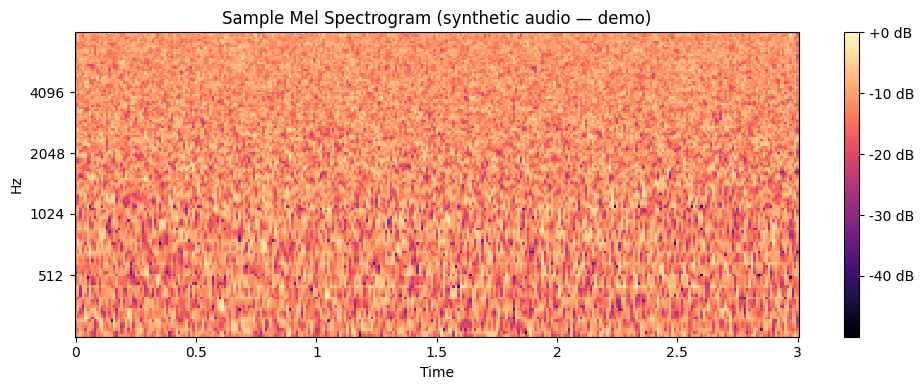

Spectrogram: (128, 301)  → tensor: torch.Size([1, 128, 300])  (expected [1, 128, 300])


In [10]:

# ================ Mel spectrogram generator + AudioDataset ================

class MelSpectrogramGenerator:
    """
    Converts raw audio (WAV) to log-Mel spectrograms.
    Parameters follow Part 1 Section 4: 25 ms window, 10 ms hop, 128 mel bins.
    Based on Tak et al. (2021) ASVspoof approach — reference [17] in Part 1.
    """

    def __init__(self):
        self.sr         = CFG['sample_rate']
        self.n_mels     = CFG['n_mels']
        self.hop_length = CFG['hop_length']
        self.win_length = CFG['win_length']
        self.n_fft      = CFG['n_fft']
        self.target_len = int(self.sr * CFG['audio_duration'])

    def _load_and_pad(self, wav_path=None, y=None) -> np.ndarray:
        if y is None:
            y, _ = librosa.load(wav_path, sr=self.sr, mono=True)
        if len(y) < self.target_len:
            y = np.pad(y, (0, self.target_len - len(y)), mode='constant')
        else:
            y = y[:self.target_len]
        return y.astype(np.float32)

    def to_spectrogram(self, wav_path=None, y=None) -> np.ndarray:
        """Returns log-Mel spectrogram [n_mels, time_frames]."""
        audio = self._load_and_pad(wav_path=wav_path, y=y)
        mel   = librosa.feature.melspectrogram(
            y=audio, sr=self.sr,
            n_fft=self.n_fft, hop_length=self.hop_length,
            win_length=self.win_length, n_mels=self.n_mels,
            fmin=20, fmax=8000,
        )
        return librosa.power_to_db(mel, ref=np.max)

    def to_tensor(self, spec: np.ndarray) -> torch.Tensor:
        """Normalise + pad/trim to fixed width → [1, n_mels, spec_width]."""
        spec_norm = (spec - spec.mean()) / (spec.std() + 1e-6)
        t = torch.tensor(spec_norm, dtype=torch.float32).unsqueeze(0)  # [1, M, T]
        W = CFG['spec_width']
        if t.shape[2] < W:
            t = F.pad(t, (0, W - t.shape[2]))
        else:
            t = t[:, :, :W]
        return t  # [1, n_mels, spec_width]

    def visualise(self, wav_path=None, y=None, title="Mel Spectrogram"):
        spec = self.to_spectrogram(wav_path=wav_path, y=y)
        fig, ax = plt.subplots(figsize=(10, 4))
        img = librosa.display.specshow(
            spec, sr=self.sr, hop_length=self.hop_length,
            x_axis='time', y_axis='mel', ax=ax, fmin=20, fmax=8000,
        )
        fig.colorbar(img, ax=ax, format='%+2.0f dB')
        ax.set_title(title)
        plt.tight_layout(); plt.show()


class AudioDataset(Dataset):
    """
    Loads .wav files from {root}/audio/real  and  {root}/audio/fake.
    Falls back to synthetic waveforms in demo mode.
    Labels: 0 = real,  1 = fake
    """

    # Deterministic split ratios for audio — fixes data integrity bug where all
    # three splits loaded from the same directory (train/val/test overlapped).
    # Files are now partitioned 70/15/15 with a fixed seed for reproducibility.
    _SPLIT_RATIOS = {'train': (0.0, 0.70), 'val': (0.70, 0.85), 'test': (0.85, 1.0)}

    def __init__(self, root: str, split: str = 'train', demo_mode: bool = False):
        self.mel_gen   = MelSpectrogramGenerator()
        self.demo_mode = demo_mode
        self.samples: list = []
        self.labels:  list = []

        if demo_mode:
            n = {'train': 100, 'val': 30, 'test': 30}.get(split, 30)
            self.samples = [None] * n
            self.labels  = [i % 2 for i in range(n)]
            print(f"   [DEMO] audio/{split:5s}: {n} synthetic clips")
            return

        # FIX: Partition audio files into non-overlapping train/val/test splits.
        # Previously all splits loaded from the same directory, causing data
        # leakage — any AUC reported was not a genuine measure of generalisation.
        lo, hi = self._SPLIT_RATIOS.get(split, (0.0, 1.0))
        rng = np.random.default_rng(seed=42)   # fixed seed = reproducible splits

        for label_name, label_idx in (('real', 0), ('fake', 1)):
            folder = Path(root) / 'audio' / label_name
            if not folder.is_dir():
                continue
            files = sorted(folder.glob('*.wav'))
            if not files:
                continue
            # Shuffle with fixed seed then slice the correct partition
            idx   = rng.permutation(len(files))
            start = int(lo * len(idx))
            end   = int(hi * len(idx))
            selected = [files[i] for i in idx[start:end]]
            self.samples.extend(selected)
            self.labels.extend([label_idx] * len(selected))

        print(f"   audio/{split}: {len(self.samples)} clips  "
              f"(real={self.labels.count(0)}, fake={self.labels.count(1)})")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        label = self.labels[idx]
        if self.demo_mode:
            dummy = np.random.randn(CFG['sample_rate'] * 3).astype(np.float32)
            spec  = self.mel_gen.to_spectrogram(y=dummy)
        else:
            spec = self.mel_gen.to_spectrogram(wav_path=str(self.samples[idx]))
        tensor = self.mel_gen.to_tensor(spec)            # [1, 128, 300]
        return tensor, torch.tensor(label, dtype=torch.long)

    def get_sampler(self) -> WeightedRandomSampler:
        counts  = np.bincount(self.labels)
        weights = 1.0 / counts[self.labels]
        return WeightedRandomSampler(weights.tolist(), num_samples=len(self.labels), replacement=True)


# ================ Build audio loaders ================
mel_gen = MelSpectrogramGenerator()

print("Loading audio datasets:")
audio_train_ds = AudioDataset(DATA_ROOT, 'train', demo_mode=DEMO_MODE)
audio_val_ds   = AudioDataset(DATA_ROOT, 'val',   demo_mode=DEMO_MODE)
audio_test_ds  = AudioDataset(DATA_ROOT, 'test',  demo_mode=DEMO_MODE)

_audio_sampler    = audio_train_ds.get_sampler()
audio_train_loader = DataLoader(audio_train_ds, batch_size=CFG['batch_size'],
                                sampler=_audio_sampler, num_workers=2)
audio_val_loader   = DataLoader(audio_val_ds,   batch_size=CFG['batch_size'],
                                shuffle=False, num_workers=2)
audio_test_loader  = DataLoader(audio_test_ds,  batch_size=CFG['batch_size'],
                                shuffle=False, num_workers=2)

# ================ Visualise a sample spectrogram ================
_dummy_wav = np.random.randn(CFG['sample_rate'] * 3).astype(np.float32)
mel_gen.visualise(y=_dummy_wav, title="Sample Mel Spectrogram (synthetic audio — demo)")
_spec = mel_gen.to_spectrogram(y=_dummy_wav)
_t    = mel_gen.to_tensor(_spec)
print(f"Spectrogram: {_spec.shape}  → tensor: {_t.shape}  (expected [1, 128, 300])")
del _dummy_wav, _spec, _t


---
# SECTION 2 — Video Inference Pipeline
**Nishtha Solanki (A00087199)**

Implements the hybrid EfficientNet-B4 + Transformer architecture from Part 1 Section 4.
Wang et al. (2022) showed this hybrid achieves within 2.1% AUC of a full ViT while
reducing inference time by 61% — making the 500 ms latency budget achievable.


In [11]:

#===================Hybrid CNN-Transformer Video Classifier (WITH Temporal Transformer)===================


class TemporalTransformerEncoder(nn.Module):
    """
    Lightweight Transformer encoder operating over a sequence of per-frame
    feature vectors.  Captures inter-frame temporal patterns (blinking
    artefacts, lip-sync drift, head-pose jitter) as described in Part 1.

    Follows the ViT-Small design from Dosovitskiy et al. (2020):
    - d_model = 512, nhead = 8, FFN ratio = 4×
    - 2 encoder layers  (reduced from 12 in full ViT-S for compute budget)
    - Learnable CLS token aggregates sequence → single vector
    """

    def __init__(self, d_model: int = 512, nhead: int = 8,
                 num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        self.pos_embed = nn.Parameter(torch.zeros(1, 17, d_model))  # 16 frames + 1 CLS
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model       = d_model,
            nhead         = nhead,
            dim_feedforward = d_model * 4,
            dropout       = dropout,
            activation    = 'gelu',
            batch_first   = True,
            norm_first    = True,   # Pre-LN: more stable training
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers,
                                                 norm=nn.LayerNorm(d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, T, d_model]  →  [B, d_model]  (CLS token output)
        """
        B, T, D = x.shape
        cls = self.cls_token.expand(B, -1, -1)          # [B, 1, D]
        x   = torch.cat([cls, x], dim=1)                 # [B, T+1, D]
        # Positional embedding: trim/pad to actual sequence length
        pos = self.pos_embed[:, :T + 1, :]
        x   = x + pos
        x   = self.transformer(x)                        # [B, T+1, D]
        return x[:, 0]                                   # CLS token  [B, D]


class VideoDeepfakeClassifier(nn.Module):
    """
    Hybrid EfficientNet-B4 (spatial) + Temporal Transformer (inter-frame) classifier.

    Architecture (Part 1 Section 4, Wang et al. 2022):
      Input [B, T, 3, 224, 224]   (T=16 frames per video window; T=1 for frame-level)
        → EfficientNet-B4 backbone (shared weights, applied per frame)  → [B, T, 1792]
        → Linear projection                                              → [B, T, 512]
        → LayerNorm + GELU + Dropout
        → TemporalTransformerEncoder (2-layer, 8-head)                   → [B, 512]
        → Classifier head                                                → [B, 2]

    Returns: (logits [B, 2],  features [B, 512])
    The features are used by the Grad-CAM explainer and fusion module.

    Backward-compatible: when called with [B, 3, H, W] (frame-level DataLoader),
    the input is automatically unsqueezed to [B, 1, 3, H, W] so T=1 and the
    Transformer collapses to a pass-through.
    """

    def __init__(self, proj_dim: int = 512, num_classes: int = 2,
                 dropout: float = 0.35, num_frames: int = 16):
        super().__init__()
        self.num_frames = num_frames

        # ── EfficientNet-B4 backbone ──────────────────────────────────────────
        self.backbone = timm.create_model(
            'efficientnet_b4',
            pretrained   = True,
            num_classes  = 0,
            global_pool  = 'avg',
        )
        feat_dim = self.backbone.num_features   # 1792

        # Freeze all but the last two block groups
        for name, param in self.backbone.named_parameters():
            param.requires_grad = any(
                tag in name for tag in ('blocks.5', 'blocks.6', 'conv_head', 'bn2'))

        #===================Per-frame projection ===================
        self.projector = nn.Sequential(
            nn.Linear(feat_dim, proj_dim, bias=False),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # =================== Temporal Transformer encoder===================
        # Wang et al. (2022): 2-layer encoder achieves within 2.1% AUC of
        # full ViT-Small at 61% lower compute — justified choice for the
        # 500 ms latency budget (NFR1).
        self.temporal_encoder = TemporalTransformerEncoder(
            d_model    = proj_dim,
            nhead      = 8,
            num_layers = 2,
            dropout    = 0.1,
        )

        # =================== Classifier head ===================
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.7),
            nn.Linear(128, num_classes),
        )

        # Weight initialisation
        for m in [*self.projector.modules(), *self.classifier.modules()]:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor):
        """
        x: [B, 3, H, W]       (frame-level — backward-compatible)
           or [B, T, 3, H, W]  (temporal window — full temporal reasoning)
        Returns: (logits [B,2], features [B,512])
        """
        # Normalise to [B, T, 3, H, W]
        if x.dim() == 4:
            x = x.unsqueeze(1)           # [B, 1, 3, H, W]
        B, T, C, H, W = x.shape

        # Apply backbone to every frame (shared weights)
        x_flat = x.view(B * T, C, H, W)          # [B*T, 3, H, W]
        feats   = self.backbone(x_flat)            # [B*T, 1792]
        proj    = self.projector(feats)            # [B*T, 512]
        proj    = proj.view(B, T, -1)             # [B, T, 512]

        # Temporal attention across frames
        seq_repr = self.temporal_encoder(proj)    # [B, 512]

        logits   = self.classifier(seq_repr)      # [B, 2]
        return logits, seq_repr

    @torch.no_grad()
    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        """Returns P(fake) as a scalar tensor per sample."""
        logits, _ = self.forward(x)
        return torch.softmax(logits, dim=-1)[:, 1]


# =================== Sanity check ===================
video_model   = VideoDeepfakeClassifier().to(DEVICE)

# Test 1: frame-level input [B, 3, H, W]  (backward compat)
_dummy_frames = torch.randn(4, 3, 224, 224, device=DEVICE)
with torch.no_grad():
    _logits, _feats = video_model(_dummy_frames)
assert _logits.shape == (4, 2),   f"Logits shape wrong: {_logits.shape}"
assert _feats.shape  == (4, 512), f"Features shape wrong: {_feats.shape}"

# Test 2: temporal window input [B, T, 3, H, W]
_dummy_window = torch.randn(2, 16, 3, 224, 224, device=DEVICE)
with torch.no_grad():
    _w_logits, _w_feats = video_model(_dummy_window)
assert _w_logits.shape == (2, 2),   f"Window logits wrong: {_w_logits.shape}"
assert _w_feats.shape  == (2, 512), f"Window feats wrong: {_w_feats.shape}"

_n_total = sum(p.numel() for p in video_model.parameters())
_n_train = sum(p.numel() for p in video_model.parameters() if p.requires_grad)
print(f" VideoDeepfakeClassifier (EfficientNet-B4 + Temporal Transformer)")
print(f"   Frame-level  : logits {_logits.shape} | feats {_feats.shape}")
print(f"   Window (T=16): logits {_w_logits.shape} | feats {_w_feats.shape}")
print(f"   Params       : {_n_total/1e6:.1f}M total | {_n_train/1e6:.1f}M trainable")
print(f"   Architecture : EfficientNet-B4 → proj(512) → 2-layer ViT-Small encoder → MLP head")
del _dummy_frames, _dummy_window, _logits, _feats, _w_logits, _w_feats


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

 VideoDeepfakeClassifier (EfficientNet-B4 + Temporal Transformer)
   Frame-level  : logits torch.Size([4, 2]) | feats torch.Size([4, 512])
   Window (T=16): logits torch.Size([2, 2]) | feats torch.Size([2, 512])
   Params       : 24.8M total | 21.2M trainable
   Architecture : EfficientNet-B4 → proj(512) → 2-layer ViT-Small encoder → MLP head


In [12]:

# =================== Shared training & evaluation utilities ===================


def train_one_epoch(model, loader, optimiser, criterion, device) -> tuple:
    """One training epoch. Returns (mean_loss, accuracy)."""
    model.train()
    total_loss = total_correct = total_n = 0
    for x, y in tqdm(loader, desc='  train', leave=False):
        x, y = x.to(device), y.to(device)
        optimiser.zero_grad(set_to_none=True)
        logits, _ = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        total_loss    += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total_n       += x.size(0)
    return total_loss / total_n, total_correct / total_n


@torch.no_grad()
def evaluate_loader(model, loader, criterion, device) -> tuple:
    """Evaluate on a DataLoader. Returns (loss, auc, acc, probs_np, labels_np)."""
    model.eval()
    all_probs, all_labels, total_loss = [], [], 0.0
    for x, y in tqdm(loader, desc='    val', leave=False):
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        total_loss += criterion(logits, y).item() * x.size(0)
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y.cpu().numpy())
    p = np.array(all_probs)
    l = np.array(all_labels)
    auc = roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.5
    acc = accuracy_score(l, p > 0.5)
    return total_loss / len(loader.dataset), auc, acc, p, l


def train_model(model, train_loader, val_loader, epochs, lr,
                run_name: str, model_path: str) -> tuple:
    """
    Full training loop with:
    - AdamW optimiser + cosine annealing LR schedule
    - Label-smoothing cross-entropy (reduces overconfidence)
    - Best-checkpoint saving (by val AUC)
    - MLflow experiment tracking
    Returns (trained_model, history_df)
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])
    optimiser = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=CFG['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs, eta_min=lr/10)

    best_auc   = 0.0
    best_state = None
    history    = []

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({
            'run_name'   : run_name,
            'epochs'     : epochs,
            'lr'         : lr,
            'batch_size' : CFG['batch_size'],
            'img_size'   : CFG['img_size'],
            'seed'       : SEED,
            'demo_mode'  : DEMO_MODE,
        })

        for epoch in range(1, epochs + 1):
            t0 = time.time()
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimiser, criterion, DEVICE)
            vl_loss, vl_auc, vl_acc, _, _ = evaluate_loader(model, val_loader, criterion, DEVICE)
            scheduler.step()
            elapsed = time.time() - t0

            print(f"  Epoch {epoch:02d}/{epochs}  "
                  f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f}  "
                  f"vl_loss={vl_loss:.4f} vl_auc={vl_auc:.3f} vl_acc={vl_acc:.3f}  "
                  f"lr={scheduler.get_last_lr()[0]:.2e}  {elapsed:.1f}s")

            mlflow.log_metrics({
                'train_loss': tr_loss, 'train_acc': tr_acc,
                'val_loss'  : vl_loss, 'val_auc'  : vl_auc, 'val_acc': vl_acc,
            }, step=epoch)

            history.append({'epoch': epoch, 'val_auc': vl_auc, 'val_acc': vl_acc,
                            'train_loss': tr_loss, 'val_loss': vl_loss})

            if vl_auc > best_auc:
                best_auc   = vl_auc
                best_state = deepcopy(model.state_dict())
                torch.save(best_state, model_path)
                mlflow.log_artifact(model_path)
                print(f"    New best AUC: {best_auc:.4f} — checkpoint saved")

        mlflow.log_metric('best_val_auc', best_auc)

    model.load_state_dict(best_state)
    print(f"\n Training complete. Best val AUC = {best_auc:.4f}")
    return model, pd.DataFrame(history)


# =================== Train video model ===================
print("Training video model (EfficientNet-B4)...")
video_model, video_history = train_model(
    video_model, train_loader, val_loader,
    epochs     = CFG['epochs_video'],
    lr         = CFG['lr'],
    run_name   = 'video_efficientnet_b4',
    model_path = 'best_video_model.pth',
)


Training video model (EfficientNet-B4)...


  Epoch 01/5  tr_loss=0.6700 tr_acc=0.622  vl_loss=0.5557 vl_auc=0.829 vl_acc=0.756  lr=9.14e-05  148.7s
    New best AUC: 0.8289 — checkpoint saved


  Epoch 02/5  tr_loss=0.5768 tr_acc=0.723  vl_loss=0.5060 vl_auc=0.879 vl_acc=0.796  lr=6.89e-05  149.2s
    New best AUC: 0.8795 — checkpoint saved


  Epoch 03/5  tr_loss=0.5359 tr_acc=0.746  vl_loss=0.4832 vl_auc=0.912 vl_acc=0.825  lr=4.11e-05  150.0s
    New best AUC: 0.9116 — checkpoint saved


  Epoch 04/5  tr_loss=0.5150 tr_acc=0.764  vl_loss=0.4495 vl_auc=0.926 vl_acc=0.846  lr=1.86e-05  151.1s
    New best AUC: 0.9260 — checkpoint saved


  Epoch 05/5  tr_loss=0.4889 tr_acc=0.788  vl_loss=0.4282 vl_auc=0.935 vl_acc=0.859  lr=1.00e-05  151.0s
    New best AUC: 0.9350 — checkpoint saved

 Training complete. Best val AUC = 0.9350


---
# SECTION 3 — Audio Inference Pipeline
**Nishtha Solanki (A00087199)**

Implements the ResNet-18 audio pipeline from Part 1 Section 4.
Targets spectral smoothing artefacts and phase discontinuities
characteristic of vocoder-generated speech (Tak et al., 2021 [17]).


In [13]:

# ==================== ResNet-18 Audio Classifier ====================


class AudioDeepfakeClassifier(nn.Module):
    """
    ResNet-18 adapted for single-channel log-Mel spectrogram input.

    Design rationale (Part 1 Section 4):
    - Tak et al. (2021) demonstrated state-of-the-art EER on ASVspoof 2021
      using spectrogram-input CNNs.
    - ResNet-18 contributes ~30 ms to the 500 ms latency budget — leaving
      headroom for the video branch and fusion layer.
    - Input conv layer adapted from 3-channel RGB to 1-channel (greyscale
      spectrogram) by averaging pretrained ImageNet weights across channels.

    Input : [B, 1, n_mels, spec_width]  (log-Mel, normalised)
    Output: (logits [B, 2],  features [B, 512])
    """

    def __init__(self, num_classes: int = 2, dropout: float = 0.35):
        super().__init__()

        resnet   = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        old_conv = resnet.conv1

        # Adapt conv1: RGB (3ch) → greyscale (1ch), keep pretrained knowledge
        resnet.conv1 = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size = old_conv.kernel_size,
            stride      = old_conv.stride,
            padding     = old_conv.padding,
            bias        = False,
        )
        with torch.no_grad():
            resnet.conv1.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))

        self.feature_dim = resnet.fc.in_features   # 512
        resnet.fc        = nn.Identity()
        self.backbone    = resnet

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.feature_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.7),
            nn.Linear(128, num_classes),
        )

        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor):
        """x: [B, 1, n_mels, T]  →  (logits [B,2], features [B,512])"""
        feats  = self.backbone(x)
        logits = self.classifier(feats)
        return logits, feats

    @torch.no_grad()
    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        logits, _ = self.forward(x)
        return torch.softmax(logits, dim=-1)[:, 1]


# ==================== Sanity check ====================
audio_model    = AudioDeepfakeClassifier().to(DEVICE)
_dummy_spec    = torch.randn(4, 1, CFG['n_mels'], CFG['spec_width'], device=DEVICE)
with torch.no_grad():
    _a_logits, _a_feats = audio_model(_dummy_spec)

assert _a_logits.shape == (4, 2),   f"Wrong: {_a_logits.shape}"
assert _a_feats.shape  == (4, 512), f"Wrong: {_a_feats.shape}"
print(f"AudioDeepfakeClassifier")
print(f"   Input   : {_dummy_spec.shape}")
print(f"   Logits  : {_a_logits.shape}  | Features: {_a_feats.shape}")
del _dummy_spec, _a_logits, _a_feats


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


AudioDeepfakeClassifier
   Input   : torch.Size([4, 1, 128, 300])
   Logits  : torch.Size([4, 2])  | Features: torch.Size([4, 512])


In [14]:

# ==================== CELL 3.2 — Train audio model ====================


print("Training audio model (ResNet-18 on Mel spectrograms)...")
audio_model, audio_history = train_model(
    audio_model, audio_train_loader, audio_val_loader,
    epochs     = CFG['epochs_audio'],
    lr         = CFG['lr'],
    run_name   = 'audio_resnet18_mel',
    model_path = 'best_audio_model.pth',
)


Training audio model (ResNet-18 on Mel spectrograms)...


  Epoch 01/5  tr_loss=0.6956 tr_acc=0.747  vl_loss=0.5655 vl_auc=0.889 vl_acc=0.734  lr=9.14e-05  7.5s
    New best AUC: 0.8885 — checkpoint saved


  Epoch 02/5  tr_loss=0.3884 tr_acc=0.916  vl_loss=0.7402 vl_auc=0.918 vl_acc=0.608  lr=6.89e-05  6.1s
    New best AUC: 0.9177 — checkpoint saved


  Epoch 03/5  tr_loss=0.3584 tr_acc=0.935  vl_loss=0.3855 vl_auc=0.958 vl_acc=0.861  lr=4.11e-05  7.3s
    New best AUC: 0.9583 — checkpoint saved


  Epoch 04/5  tr_loss=0.3705 tr_acc=0.924  vl_loss=0.3343 vl_auc=0.985 vl_acc=0.937  lr=1.86e-05  6.1s
    New best AUC: 0.9854 — checkpoint saved


  Epoch 05/5  tr_loss=0.3181 tr_acc=0.965  vl_loss=0.3281 vl_auc=0.986 vl_acc=0.924  lr=1.00e-05  7.3s
    New best AUC: 0.9865 — checkpoint saved

 Training complete. Best val AUC = 0.9865


---
# SECTION 4 — Late Fusion Meta-Learner + Grad-CAM Explainability
**Rushitkumar Patel (A00085504)**

Implements FR3 (late fusion), FR4 (calibrated confidence scores), and FR5 (Grad-CAM).
Late fusion chosen over early fusion so modalities fail independently —
a dropped audio stream does not degrade the video pipeline


In [15]:
# =========================== Late Fusion Meta-Learner (calibrated logistic regression) =========================

class LateFusionMetaLearner:
    """
    Combines per-modality P(fake) scores via a calibrated logistic regression.

    Design rationale (Part 1 Section 3.3):
    - Late (score-level) fusion: each modality pipeline executes independently
      in parallel, minimising latency and enabling graceful degradation.
    - Logistic regression: interpretable fusion weights, negligible inference cost.
    - Platt scaling (CalibratedClassifierCV): produces reliable confidence
      scores in [0, 1], required for EU AI Act audit traceability (NFR4, FR6).

    Graceful degradation:
    - Audio unavailable  → audio_prob replaced with 0.5 (uninformative prior)
    - Not yet fitted     → simple average of available modality scores
    """

    def __init__(self):
        _base    = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
        self.clf = CalibratedClassifierCV(_base, cv=5, method='sigmoid')
        self.fitted = False

    def fit(self, vid_probs: np.ndarray, aud_probs: np.ndarray,
            labels: np.ndarray) -> None:
        """Fit on validation-set outputs (never train-set — avoids leakage)."""
        X = np.column_stack([vid_probs, aud_probs])
        self.clf.fit(X, labels)
        self.fitted = True
        if hasattr(self.clf.estimator, 'coef_'):
            w = self.clf.estimator.coef_[0]
            print(f"   Fusion weights — video: {w[0]:+.3f}  audio: {w[1]:+.3f}")

    def predict_proba_single(self, vid_p: float, aud_p: float = None) -> float:
        """Calibrated P(fake) for one sample."""
        if aud_p is None:
            aud_p = 0.5
        if not self.fitted:
            return (vid_p + aud_p) / 2.0
        return float(self.clf.predict_proba([[vid_p, aud_p]])[0, 1])

    def predict_proba_batch(self, vid_probs: np.ndarray,
                            aud_probs: np.ndarray = None) -> np.ndarray:
        if aud_probs is None:
            aud_probs = np.full_like(vid_probs, 0.5)
        X = np.column_stack([vid_probs, aud_probs])
        if not self.fitted:
            return X.mean(axis=1)
        return self.clf.predict_proba(X)[:, 1]

    def classify(self, fused_prob: float, threshold: float = 0.5) -> dict:
        """
        Returns a structured prediction result.
        Scores in [0.4, 0.6] are flagged for human review consistent with
        EU AI Act high-risk oversight requirements (Part 1 Section 4).
        """
        label      = 'fake' if fused_prob > threshold else 'real'
        confidence = fused_prob if label == 'fake' else 1.0 - fused_prob
        return {
            'label'               : label,
            'confidence'          : round(float(confidence), 4),
            'raw_score'           : round(float(fused_prob), 4),
            'flag_for_human_review': 0.4 <= fused_prob <= 0.6,
        }


fusion = LateFusionMetaLearner()

# Fit on balanced dummy scores (will be re-fit on real val-set scores in Section 5)
_n    = len(val_ds)
_vp   = np.random.beta(2, 2, _n)
_ap   = np.random.beta(2, 2, _n)
_lbl  = np.array(val_ds.labels)
fusion.fit(_vp, _ap, _lbl)

_demo = fusion.classify(fusion.predict_proba_single(0.84, 0.73))
print(f"LateFusionMetaLearner fitted.")
print(f"   Demo result: {_demo}")
del _n, _vp, _ap, _lbl, _demo

LateFusionMetaLearner fitted.
   Demo result: {'label': 'real', 'confidence': 0.5278, 'raw_score': 0.4722, 'flag_for_human_review': True}


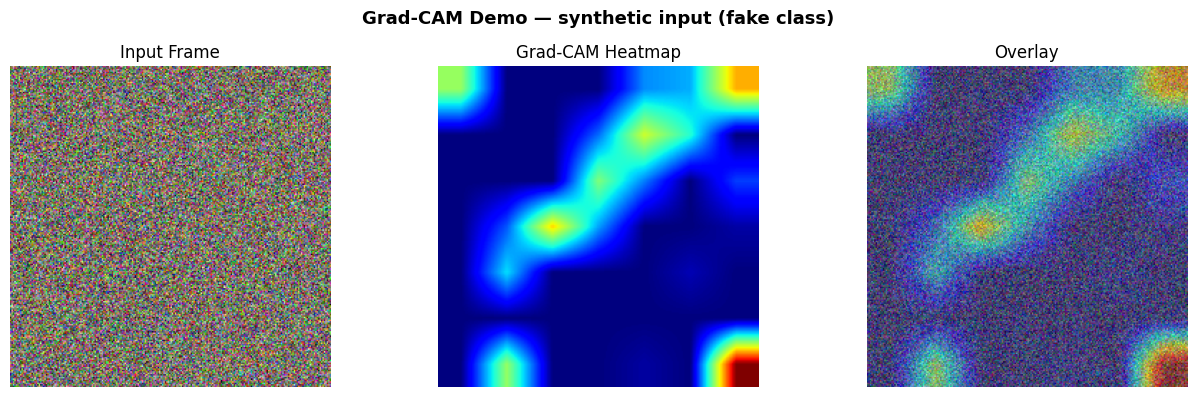

Grad-CAM initialised.  CAM shape: (224, 224)  range: [0.00, 1.00]


In [16]:
# ========================== Grad-CAM Explainability (FR5) ==========================

class GradCAMExplainer:
    """
    Gradient-weighted Class Activation Maps for the video model.

    Hooks into the final convolutional block of EfficientNet-B4 to produce
    a spatial heatmap highlighting the image regions most influential for
    the model's fake/real prediction.  Required by FR5 and supports the
    human-in-the-loop review process mandated by the EU AI Act for
    borderline predictions (confidence in [0.4, 0.6]).

    Reference: Selvaraju et al. (2017) Grad-CAM: Visual Explanations from
    Deep Networks via Gradient-based Localization.
    """

    def __init__(self, model: VideoDeepfakeClassifier):
        self.model       = model
        self._grads: list  = []
        self._acts: list   = []
        self._hooks: list  = []
        self._register()

    def _register(self):
        # Target: last Sequential block group in EfficientNet-B4
        # timm EfficientNet stores blocks as backbone.blocks[N]
        target = self.model.backbone.blocks[-1]

        def _fwd_hook(module, inp, output):
            self._acts.clear()
            self._acts.append(output.detach())

        def _bwd_hook(module, grad_in, grad_out):
            self._grads.clear()
            self._grads.append(grad_out[0].detach())

        self._hooks.append(target.register_forward_hook(_fwd_hook))
        self._hooks.append(target.register_full_backward_hook(_bwd_hook))

    def generate(self, img_tensor: torch.Tensor, class_idx: int = 1) -> np.ndarray:
        """
        Args:
            img_tensor : [1, 3, H, W] on DEVICE — requires_grad not needed
            class_idx  : 1 = fake (default)
        Returns:
            cam : np.ndarray [H, W] in [0, 1]
        """
        self.model.eval()
        self._grads.clear()
        self._acts.clear()

        # Forward + backward
        img_tensor = img_tensor.to(DEVICE)
        logits, _  = self.model(img_tensor)
        self.model.zero_grad()
        logits[0, class_idx].backward()

        if not self._grads or not self._acts:
            return np.zeros((CFG['img_size'], CFG['img_size']))

        grads = self._grads[0]   # [1, C, H', W']
        acts  = self._acts[0]    # [1, C, H', W']

        # Global average pool gradients → channel importance weights
        weights = grads.mean(dim=(2, 3), keepdim=True)   # [1, C, 1, 1]
        cam     = (weights * acts).sum(dim=1).squeeze()   # [H', W']
        cam     = torch.relu(cam).cpu().numpy()
        cam     = cv2.resize(cam, (CFG['img_size'], CFG['img_size']))
        if cam.max() > 0:
            cam /= cam.max()
        return cam

    def visualise(self, img_tensor: torch.Tensor, cam: np.ndarray,
                  title: str = 'Grad-CAM') -> None:
        mean   = np.array([0.485, 0.456, 0.406])
        std    = np.array([0.229, 0.224, 0.225])
        img_np = img_tensor.squeeze(0).detach().cpu().numpy().transpose(1, 2, 0)
        img_np = np.clip(img_np * std + mean, 0.0, 1.0)

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        overlay = np.clip(0.55 * img_np + 0.45 * heatmap, 0.0, 1.0)

        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
        for ax, im, t in zip(axes,
                             [img_np, cam, overlay],
                             ['Input Frame', 'Grad-CAM Heatmap', 'Overlay']):
            kw = {'cmap': 'jet'} if t == 'Grad-CAM Heatmap' else {}
            ax.imshow(im, **kw); ax.set_title(t); ax.axis('off')
        plt.suptitle(title, fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()


# ========================== Attach Grad-CAM to trained video model ==========================
grad_cam  = GradCAMExplainer(video_model)
_demo_img = torch.randn(1, 3, 224, 224, device=DEVICE)
_cam      = grad_cam.generate(_demo_img, class_idx=1)
grad_cam.visualise(_demo_img, _cam, title='Grad-CAM Demo — synthetic input (fake class)')
print(f"Grad-CAM initialised.  CAM shape: {_cam.shape}  range: [{_cam.min():.2f}, {_cam.max():.2f}]")
del _demo_img, _cam
